# WM 2026 — Live-Update: Tabellen, nächste Spiele & neue Titelchancen

**Begleit-Notebook zu** *Soccer Analytics with Machine Learning* (O'Reilly, 2026).

Dieses Notebook nimmt die **echten WM-2026-Ergebnisse** (sobald gespielt) und rechnet
laufend alles neu:

1. **Aktuelle Gruppentabellen** aus den bereits gespielten Spielen.
2. **Prognose der nächsten Spiele** — Sieg/Remis/Niederlage + wahrscheinlichstes Ergebnis.
3. **Das offizielle K.-o.-Bracket** (Achtelfinale der 32 = Round of 32 → Finale),
   das in `data/wc2026_fixtures.csv` hinterlegt ist, inkl. korrekter Zuordnung der
   acht besten Gruppendritten.
4. **Aktualisierte WM-Chancen** für jedes Team (Achtel-/Viertel-/Halbfinale, Finale,
   Titel) per **Hybrid-Monte-Carlo**: gespielte Ergebnisse stehen fest, der Rest wird
   tausendfach simuliert.

**Datenquelle:** das öffentliche [openfootball](https://github.com/openfootball)-Projekt
(Public Domain). Das Notebook lädt live; bei fehlendem Netz nutzt es den committeten
Snapshot `data/wc2026_results.csv`. Aktualisieren mit `python refresh_data.py`.

> ⚠️ Ergebnisse aus openfootball können vorläufig sein — vor Veröffentlichung gegen
> eine offizielle Quelle prüfen. Stärke-Werte (`STRENGTH`) sind ein Snapshot; siehe
> Abschnitt *„Was muss aktualisiert werden?"*.

## 1. Setup & Modell-Kern

Wir kalibrieren dasselbe Poisson-Tormodell wie in den anderen Notebooks auf 358
echten Länderspielen und definieren die Ergebnis-/Wahrscheinlichkeitsfunktionen.

In [1]:
import warnings; warnings.filterwarnings("ignore")
import json, urllib.request
import numpy as np, pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt, matplotlib as mpl
from matplotlib.colors import LinearSegmentedColormap
from scipy.stats import poisson as pois, nbinom
from scipy.optimize import linear_sum_assignment
import statsmodels.api as sm

rng = np.random.default_rng(2026)
DATA = Path("data")
NAVY, RED, GREEN, AMBER, GREY = "#1E2761", "#B85042", "#2E7D5B", "#E0A040", "#8A8D93"
SCORE_CMAP = LinearSegmentedColormap.from_list("wc", ["#F7F9FC", "#9FB6D6", NAVY])
mpl.rcParams.update({"font.family":"DejaVu Sans","font.size":11,"axes.spines.top":False,
    "axes.spines.right":False,"axes.titleweight":"bold","figure.dpi":110,
    "savefig.dpi":150,"savefig.bbox":"tight"})

GROUPS = {
    "A":["Mexico","South Africa","South Korea","Czechia"],"B":["Canada","Bosnia-Herzegovina","Qatar","Switzerland"],
    "C":["Brazil","Morocco","Haiti","Scotland"],"D":["United States","Paraguay","Australia","Türkiye"],
    "E":["Germany","Curacao","Ivory Coast","Ecuador"],"F":["Netherlands","Japan","Sweden","Tunisia"],
    "G":["Belgium","Egypt","Iran","New Zealand"],"H":["Spain","Cape Verde","Saudi Arabia","Uruguay"],
    "I":["France","Senegal","Iraq","Norway"],"J":["Argentina","Algeria","Austria","Jordan"],
    "K":["Portugal","Congo DR","Uzbekistan","Colombia"],"L":["England","Croatia","Ghana","Panama"],
}
TEAMS = [t for g in GROUPS.values() for t in g]; ix = {t:i for i,t in enumerate(TEAMS)}
STRENGTH = {
    "Spain":2165,"Argentina":2120,"France":2100,"England":2055,"Brazil":2025,"Netherlands":2030,
    "Portugal":2010,"Germany":1965,"Belgium":1950,"Croatia":1945,"Uruguay":1930,"Colombia":1915,
    "Morocco":1900,"Japan":1900,"Senegal":1895,"Switzerland":1860,"Norway":1855,"Austria":1850,
    "Ecuador":1840,"Türkiye":1840,"Mexico":1820,"Czechia":1815,"Sweden":1815,"United States":1805,
    "Iran":1800,"Ivory Coast":1800,"Algeria":1795,"South Korea":1790,"Scotland":1780,"Egypt":1780,
    "Canada":1780,"Ghana":1750,"Paraguay":1720,"Australia":1720,"Congo DR":1720,"Bosnia-Herzegovina":1710,
    "Tunisia":1700,"Qatar":1680,"Uzbekistan":1680,"Saudi Arabia":1655,"Iraq":1650,"Panama":1650,
    "South Africa":1640,"Jordan":1600,"Cape Verde":1555,"Curacao":1530,"Haiti":1500,"New Zealand":1500,
    "Italy":1990,"Denmark":1870,"Poland":1825,"Serbia":1820,"Chile":1815,"Russia":1815,"Nigeria":1810,
    "Ukraine":1800,"Greece":1800,"Hungary":1795,"Wales":1790,"Cameroon":1760,"Slovakia":1760,
    "Slovenia":1760,"Romania":1755,"Peru":1750,"Iceland":1740,"Georgia":1735,"Albania":1730,
    "North Macedonia":1720,"Finland":1715,"Costa Rica":1700,"Honduras":1620,"North Korea":1600,
}

def load_matches():
    cols = ["home_team","away_team","home_score","away_score","knockout"]
    m = pd.concat([pd.read_csv(DATA/"worldcup_matches.csv")[cols],
                   pd.read_csv(DATA/"recent_internationals.csv")[cols]], ignore_index=True)
    m = m[m.home_team.isin(STRENGTH) & m.away_team.isin(STRENGTH)].copy()
    m["sdiff"] = m.home_team.map(STRENGTH) - m.away_team.map(STRENGTH)
    m["res"]   = np.sign(m.home_score - m.away_score).astype(int)
    return m
M = load_matches()
gl = pd.DataFrame({"goals": np.r_[M.home_score, M.away_score], "sd": np.r_[M.sdiff, -M.sdiff]})
pois_fit = sm.GLM(gl.goals, sm.add_constant(gl[["sd"]]), family=sm.families.Poisson()).fit()
B0, B1 = pois_fit.params["const"], pois_fit.params["sd"]
alpha  = max(1e-3, (pois_fit.pearson_chi2/pois_fit.df_resid - 1))
dz = sm.add_constant(pd.DataFrame({"abs": M.sdiff.abs()}))
draw_fit = sm.GLM((M.res==0).astype(int), dz, family=sm.families.Binomial()).fit()
def pdraw(absd):
    return float(draw_fit.predict(sm.add_constant(pd.DataFrame({"abs":[absd]}), has_constant="add"))[0])

def lam(a, b, ratings=STRENGTH):
    d = ratings[a]-ratings[b]; return float(np.exp(B0+B1*d)), float(np.exp(B0-B1*d))

def scoreline(a, b, ratings=STRENGTH, dispersion=0.0, maxg=7):
    la, lb = lam(a, b, ratings); g = np.arange(maxg+1)
    def pmf(l):
        if dispersion > 1e-6:
            rr = 1.0/dispersion; return nbinom.pmf(g, rr, rr/(rr+l))
        return pois.pmf(g, l)
    P = np.outer(pmf(la), pmf(lb)); P /= P.sum(); return P, la, lb

def wdl(a, b, ratings=STRENGTH):
    P, _, _ = scoreline(a, b, ratings)
    return np.tril(P,-1).sum(), np.trace(P), np.triu(P,1).sum()   # win1, draw, win2

def modal_score(a, b, ratings=STRENGTH):
    P, la, lb = scoreline(a, b, ratings); n = P.shape[0]; i, j = divmod(int(np.argmax(P)), n)
    return f"{i}:{j}", P[i, j]*100

# --- rating models computed from the same 358 results (Ch 8) ---
def _colley():
    teams = sorted(set(M.home_team)|set(M.away_team)); idx = {t:i for i,t in enumerate(teams)}; n=len(teams)
    C = np.eye(n)*2; b = np.ones(n)
    for _, r in M.iterrows():
        i,j = idx[r.home_team], idx[r.away_team]; C[i,i]+=1; C[j,j]+=1; C[i,j]-=1; C[j,i]-=1
        wi = 1.0 if r.res>0 else (0.5 if r.res==0 else 0.0); b[i]+=wi-0.5; b[j]+=(1-wi)-0.5
    x = np.linalg.solve(C, b); return {t:x[idx[t]] for t in teams}
def _pagerank(d=0.85, it=100):
    teams = sorted(set(M.home_team)|set(M.away_team)); idx = {t:i for i,t in enumerate(teams)}; n=len(teams)
    W = np.zeros((n,n))
    for _, r in M.iterrows():
        i,j = idx[r.home_team], idx[r.away_team]
        if r.res>0: W[j,i]+=1
        elif r.res<0: W[i,j]+=1
        else: W[i,j]+=.5; W[j,i]+=.5
    cs = W.sum(1,keepdims=True); cs[cs==0]=1; T=W/cs; pr=np.ones(n)/n
    for _ in range(it): pr = (1-d)/n + d*(T.T@pr)
    return {t:pr[idx[t]] for t in teams}
def _to_elo(rat):
    v = np.array(list(rat.values())); mu, sd = v.mean(), v.std()+1e-9
    return {t:(1850+(rat[t]-mu)/sd*130) if t in rat else STRENGTH[t] for t in TEAMS}
COLLEY = _to_elo(_colley()); PAGER = _to_elo(_pagerank())

# --- the five match models that yield win/draw/loss directly ---
def model_wdl(a, b, R=STRENGTH):
    """P(Sieg/Remis/Niederlage) je Modell als dict {Name: (w, d, l)}; R = Staerke-Basis."""
    out = {"Poisson": wdl(a, b, R)}
    P = scoreline(a, b, R, alpha)[0]
    out["Neg.Binom"] = (np.tril(P,-1).sum(), np.trace(P), np.triu(P,1).sum())
    da = R[a]-R[b]; we = 1/(1+10**(-da/400)); pdr = pdraw(abs(da))
    out["Elo"]      = ((1-pdr)*we, pdr, (1-pdr)*(1-we))
    out["Colley"]   = wdl(a, b, COLLEY)
    out["PageRank"] = wdl(a, b, PAGER)
    return out
MATCH_MODELS = ["Poisson", "Neg.Binom", "Elo", "Colley", "PageRank"]
def wdl_consensus(a, b, R=STRENGTH):
    arr = np.array(list(model_wdl(a, b, R).values())).mean(0); return arr/arr.sum()

SIM_MODEL = "Poisson-Tor-Sampling (Tore ~ Poisson(λ) je Team)"
print(f"Kalibriert auf {len(M)} Spielen · λ(Gleichstärke) = {np.exp(B0):.2f} Tore · NB-α = {alpha:.3f}")
print("W/U/N-Konsens-Modelle :", ", ".join(MATCH_MODELS))
print("Wahrscheinlichstes Ergebnis: Modus (argmax) der Poisson-Ergebnis-Matrix")
print("Simulationsmodell (Titel)  :", SIM_MODEL)


Kalibriert auf 358 Spielen · λ(Gleichstärke) = 1.18 Tore · NB-α = 0.008
W/U/N-Konsens-Modelle : Poisson, Neg.Binom, Elo, Colley, PageRank
Wahrscheinlichstes Ergebnis: Modus (argmax) der Poisson-Ergebnis-Matrix
Simulationsmodell (Titel)  : Poisson-Tor-Sampling (Tore ~ Poisson(λ) je Team)


### 1.1 Welche Algorithmen stecken drin? (Details)

| Baustein | Algorithmus | Idee |
|----------|-------------|------|
| **Erwartete Tore λ** | Poisson-GLM (Ch 4) | λ = exp(β₀ + β₁·Stärkedifferenz), kalibriert auf 358 Spielen |
| **W/U/N-Konsens** | Mittel aus **5 Modellen** | Poisson · Negative Binomial · Elo · Colley · PageRank |
| **Wahrscheinlichstes Ergebnis** | Modus der Poisson-Matrix | argmax über P(h:a) = Poisson(h\|λ₁)·Poisson(a\|λ₂) |
| **Titel-Simulation** | Poisson-Tor-Sampling | je Spiel Tore ~ Poisson(λ), 8 000 ganze Turniere |
| **Gruppendritte → Bracket** | gültiges Matching | acht beste Dritte auf die erlaubten R32-Slots |

> **Wichtig zum „wahrscheinlichsten Ergebnis":** Das ist der **Modus** (das einzelne
> häufigste exakte Resultat), **nicht** der Mittelwert. Bei Poisson verteilt sich die
> Wahrscheinlichkeit über viele hohe Resultate, daher ist der Modus meist knapp
> (1:0, 2:0). Die **Dominanz** liest man an **λ** (erwartete Tore) und an **W/U/N** ab —
> siehe die Erklärung unter den nächsten Spielen.

Jede Ausgabe-Tabelle nennt in ihrer Überschrift, welche Algorithmen sie verwendet.

## 2. Aktuelle WM-2026-Daten laden

Erst Live-Download von openfootball (Namens-Normalisierung via `refresh_data.py`),
sonst der lokale Snapshot. Ergebnis ist der komplette Spielplan inkl. der bereits
gespielten Ergebnisse.

In [2]:
URL = "https://raw.githubusercontent.com/openfootball/worldcup.json/master/2026/worldcup.json"
NAME_MAP = {"Czech Republic":"Czechia","Bosnia & Herzegovina":"Bosnia-Herzegovina","Turkey":"Türkiye",
            "USA":"United States","Curaçao":"Curacao","DR Congo":"Congo DR","Korea Republic":"South Korea",
            "IR Iran":"Iran","Côte d'Ivoire":"Ivory Coast"}
def _norm(t): return NAME_MAP.get(t, t)

def load_live():
    try:
        req = urllib.request.Request(URL, headers={"User-Agent":"wc2026-model/1.0"})
        with urllib.request.urlopen(req, timeout=20) as r:
            doc = json.loads(r.read().decode("utf-8"))
        rows = []
        for m in doc["matches"]:
            ft = (m.get("score") or {}).get("ft"); grp = (m.get("group") or "").replace("Group ","").strip()
            rows.append({"date":m.get("date",""),"round":m.get("round",""),"group":grp,
                         "team1":_norm(m["team1"]),"team2":_norm(m["team2"]),
                         "score1": np.nan if not ft else ft[0], "score2": np.nan if not ft else ft[1]})
        return pd.DataFrame(rows), "live von openfootball geladen"
    except Exception as e:
        df = pd.read_csv(DATA/"wc2026_results.csv")
        return df, f"lokaler Snapshot data/wc2026_results.csv (kein Live-Zugriff: {type(e).__name__})"

sched, source = load_live()
sched["score1"] = pd.to_numeric(sched["score1"], errors="coerce")
sched["score2"] = pd.to_numeric(sched["score2"], errors="coerce")
sched["played"] = sched["score1"].notna() & sched["score2"].notna()
grp_played = sched[(sched.group.astype(str).str.len()>0) & sched.group.notna() & sched.played]
n_grp = ((sched.group.astype(str).str.len()>0) & sched.group.notna()).sum()
print(f"Quelle: {source}")
print(f"Spielplan: {len(sched)} Partien · {sched.played.sum()} gespielt "
      f"({len(grp_played)}/{n_grp} Gruppenspiele).")
sched[sched.played].tail(8)[["date","group","team1","score1","score2","team2"]]


Quelle: live von openfootball geladen
Spielplan: 104 Partien · 32 gespielt (32/72 Gruppenspiele).


,date,group,team1,score1,score2,team2
48,2026-06-16,I,France,3.0,1.0,Senegal
49,2026-06-16,I,Iraq,1.0,4.0,Norway
54,2026-06-16,J,Argentina,3.0,0.0,Algeria
55,2026-06-16,J,Austria,3.0,1.0,Jordan
60,2026-06-17,K,Portugal,1.0,1.0,Congo DR
61,2026-06-17,K,Uzbekistan,1.0,3.0,Colombia
66,2026-06-17,L,England,4.0,2.0,Croatia
67,2026-06-17,L,Ghana,1.0,0.0,Panama


## 3. Aktuelle Gruppentabellen

Aus den bereits gespielten Spielen — Punkte, Tordifferenz, Tore. Noch nicht
gespielte Partien fließen hier nicht ein.

In [3]:
def current_tables(sched):
    rows = []
    for g in GROUPS:
        tab = {t: dict(Sp=0, S=0, U=0, N=0, Tore=0, Geg=0, Pkt=0) for t in GROUPS[g]}
        gm = sched[(sched.group==g) & sched.played]
        for _, m in gm.iterrows():
            a, b, x, y = m.team1, m.team2, int(m.score1), int(m.score2)
            if a not in tab or b not in tab: continue
            for t, gf, ga in ((a,x,y),(b,y,x)):
                tab[t]["Sp"]+=1; tab[t]["Tore"]+=gf; tab[t]["Geg"]+=ga
            if x>y:  tab[a]["S"]+=1; tab[a]["Pkt"]+=3; tab[b]["N"]+=1
            elif y>x:tab[b]["S"]+=1; tab[b]["Pkt"]+=3; tab[a]["N"]+=1
            else:    tab[a]["U"]+=1; tab[b]["U"]+=1; tab[a]["Pkt"]+=1; tab[b]["Pkt"]+=1
        order = sorted(GROUPS[g], key=lambda t:(tab[t]["Pkt"], tab[t]["Tore"]-tab[t]["Geg"],
                                                tab[t]["Tore"], STRENGTH[t]), reverse=True)
        for pos, t in enumerate(order, 1):
            d = tab[t]; rows.append({"Gr.":g,"Pos":pos,"Team":t,"Sp":d["Sp"],"S":d["S"],"U":d["U"],
                "N":d["N"],"Tore":f'{d["Tore"]}:{d["Geg"]}',"Diff":d["Tore"]-d["Geg"],"Pkt":d["Pkt"]})
    return pd.DataFrame(rows)

tables = current_tables(sched)
def _hi(row):
    c = "background-color:#d7e9d2" if row.Pos<=2 else ("background-color:#fbf3d6" if row.Pos==3 else "")
    return [c]*len(row)
(tables.style.apply(_hi, axis=1).hide(axis="index")
    .set_caption("Aktuelle Gruppentabellen (grün = Platz 1–2, gelb = Platz 3 / mögl. bester Dritter)"))


Gr.,Pos,Team,Sp,S,U,N,Tore,Diff,Pkt
A,1,Mexico,2,2,0,0,3:0,3,6
A,2,South Korea,2,1,0,1,2:2,0,3
A,3,Czechia,2,0,1,1,2:3,-1,1
A,4,South Africa,2,0,1,1,1:3,-2,1
B,1,Canada,2,1,1,0,7:1,6,4
B,2,Switzerland,2,1,1,0,5:2,3,4
B,3,Bosnia-Herzegovina,2,0,1,1,2:5,-3,1
B,4,Qatar,2,0,1,1,1:7,-6,1
C,1,Brazil,2,1,1,0,4:1,3,4
C,2,Morocco,2,1,1,0,2:1,1,4


## 4. Prognose der anstehenden Spiele

**Alle** noch nicht gespielten Partien mit bekannten Teams (also die restlichen
Gruppenspiele) — mit Sieg/Remis/Niederlage-Konsens (Mittel aus Poisson, Negative
Binomial, Elo, Colley, PageRank), erwarteten Toren λ und dem wahrscheinlichsten
exakten Ergebnis (Poisson). K.-o.-Paarungen erscheinen erst nach der
Gruppenphase als echte Teams (bis dahin Platzhalter wie `2A`, `W74`) — ihre
Prognose steht in Abschnitt 7.

In [4]:
def next_matches(sched, k=None, R=STRENGTH):
    up = sched[~sched.played].copy()
    up = up[up.team1.isin(STRENGTH) & up.team2.isin(STRENGTH)].sort_values("date")
    if k: up = up.head(k)
    out = []
    for _, m in up.iterrows():
        a, b = m.team1, m.team2; w, d, l = wdl_consensus(a, b, R)
        la, lb = lam(a, b, R); s, p = modal_score(a, b, R)
        tag = m.group if isinstance(m.group,str) and m.group else m["round"]
        out.append({"Datum":m.date,"Runde":tag,"Begegnung":f"{a} – {b}",
                    "Ø Tore (λ)":f"{la:.1f} : {lb:.1f}",
                    "P(Sieg 1)":w*100,"P(Remis)":d*100,"P(Sieg 2)":l*100,
                    "wahrsch. Erg.":s,"P(Erg.)":p})
    return pd.DataFrame(out)

nxt = next_matches(sched)                      # alle anstehenden Spiele mit bekannten Teams
print(f"{len(nxt)} anstehende Partien mit bekannten Teams (die restlichen Gruppenspiele). "
      f"K.-o.-Paarungen stehen erst nach der Gruppenphase fest — siehe Abschnitt 7.")
(nxt.style.hide(axis="index")
   .format({"P(Sieg 1)":"{:.0f}%","P(Remis)":"{:.0f}%","P(Sieg 2)":"{:.0f}%","P(Erg.)":"{:.0f}%"})
   .background_gradient(cmap="Greens", subset=["P(Sieg 1)"])
   .background_gradient(cmap="Reds",   subset=["P(Sieg 2)"])
   .set_caption("Alle anstehenden Spiele mit bekannten Teams — W/U/N-Konsens aus 5 Modellen "
                "(Poisson, Neg.Binom, Elo, Colley, PageRank). Ø Tore (λ) = erwartete Tore. "
                "wahrsch. Erg. = wahrscheinlichstes exaktes Ergebnis (Modus)."))


40 anstehende Partien mit bekannten Teams (die restlichen Gruppenspiele). K.-o.-Paarungen stehen erst nach der Gruppenphase fest — siehe Abschnitt 7.


Datum,Runde,Begegnung,Ø Tore (λ),P(Sieg 1),P(Remis),P(Sieg 2),wahrsch. Erg.,P(Erg.)
2026-06-20,F,Tunisia – Japan,0.9 : 1.6,22%,26%,52%,0:1,14%
2026-06-20,E,Germany – Ivory Coast,1.5 : 0.9,57%,24%,19%,1:0,13%
2026-06-20,E,Ecuador – Curacao,2.0 : 0.7,66%,21%,12%,1:0,14%
2026-06-20,F,Netherlands – Sweden,1.7 : 0.8,58%,24%,18%,1:0,14%
2026-06-21,H,Uruguay – Cape Verde,2.2 : 0.6,73%,18%,8%,2:0,14%
2026-06-21,H,Spain – Saudi Arabia,2.7 : 0.5,79%,16%,6%,2:0,15%
2026-06-21,G,New Zealand – Egypt,0.7 : 1.9,29%,24%,47%,0:1,14%
2026-06-21,G,Belgium – Iran,1.5 : 0.9,55%,25%,20%,1:0,13%
2026-06-22,I,Norway – Senegal,1.1 : 1.3,34%,28%,38%,1:1,13%
2026-06-22,I,France – Iraq,2.5 : 0.6,79%,15%,6%,2:0,15%


### 4.1 Algorithmus-Details: die fünf Modelle für das nächste Spiel

Damit transparent ist, *woraus* der Konsens entsteht: hier die einzelne
W/U/N-Einschätzung jedes der fünf Modelle für die nächste anstehende Partie.

In [5]:
upcoming = (sched[~sched.played & sched.team1.isin(STRENGTH) & sched.team2.isin(STRENGTH)]
            .sort_values("date"))
a0, b0 = upcoming.iloc[0].team1, upcoming.iloc[0].team2
detail = pd.DataFrame(model_wdl(a0, b0), index=["Sieg","Unentschieden","Niederlage"]).T * 100
detail.index.name = "Modell"
la0, lb0 = lam(a0, b0)
print(f"Nächstes Spiel: {a0} vs {b0}   ·   erwartete Tore λ = {la0:.2f} : {lb0:.2f}")
(detail.style.format("{:.1f}%")
   .background_gradient(cmap="Greens",  subset=["Sieg"])
   .background_gradient(cmap="Oranges", subset=["Unentschieden"])
   .background_gradient(cmap="Reds",    subset=["Niederlage"])
   .set_caption(f"{a0} vs {b0} — Sieg/Remis/Niederlage je Algorithmus (Spalten = aus Sicht von {a0})"))


Nächstes Spiel: Tunisia vs Japan   ·   erwartete Tore λ = 0.85 : 1.64


,Sieg,Unentschieden,Niederlage
Modell,,,
Poisson,19.4%,24.6%,56.0%
Neg.Binom,19.5%,24.6%,55.9%
Elo,17.7%,26.4%,55.9%
Colley,29.5%,27.5%,43.0%
PageRank,24.2%,26.3%,49.5%


### 4.2 Warum stehen da meist knappe Ergebnisse (1:0, 2:0)?

Die Spalte **„wahrsch. Erg."** zeigt das **wahrscheinlichste *einzelne* exakte
Ergebnis** (den **Modus**) — nicht den Mittelwert. Beispiel **Brasilien – Haiti**:

* erwartete Tore **λ = 2,4 : 0,6**, Sieg-Wahrscheinlichkeit **77 %**,
* aber die Wahrscheinlichkeit verteilt sich: 2:0 (14 %), 1:0 (12 %), 3:0 (11 %),
  2:1 (9 %), 1:1 (7 %), 3:1 (7 %) …

Kein *einzelnes* hohes Ergebnis hat so viel Masse wie 2:0 — deshalb ist der Modus
fast immer knapp, **obwohl** Brasilien klar dominiert (≥3 Tore Unterschied in ~31 %
der Fälle). Die echte Überlegenheit liest man daher an **λ** und an **W/U/N** ab,
nicht am Modus. Wer das „typische" Ergebnis möchte, rundet λ (≈ 2–3 : 0–1).

## 5. Das offizielle K.-o.-Bracket

Das Bracket ist fest vorgegeben (`data/wc2026_fixtures.csv`): Round of 32 mit
Slots wie `1A`, `2B`, `3A/B/C/D/F`, dann R16 → Viertel- → Halbfinale → Finale.
Die acht besten Gruppendritten werden den Slots nach FIFA-Regel (erlaubte Gruppen
je Slot) zugeordnet — hier per gültiger Zuordnung (Matching).

In [6]:
# Round of 32:  (Match-Nr, Slot1, Slot2);  "3:XYZ" = bester Dritter aus einer der Gruppen XYZ
R32 = [(73,"2A","2B"),(74,"1E","3:ABCDF"),(75,"1F","2C"),(76,"1C","2F"),
       (77,"1I","3:CDFGH"),(78,"2E","2I"),(79,"1A","3:CEFHI"),(80,"1L","3:EHIJK"),
       (81,"1D","3:BEFIJ"),(82,"1G","3:AEHIJ"),(83,"2K","2L"),(84,"1H","2J"),
       (85,"1B","3:EFGIJ"),(86,"1J","2H"),(87,"1K","3:DEIJL"),(88,"2D","2G")]
R16 = [(89,74,77),(90,73,75),(91,76,78),(92,79,80),(93,83,84),(94,81,82),(95,86,88),(96,85,87)]
QF  = [(97,89,90),(98,93,94),(99,91,92),(100,95,96)]
SF  = [(101,97,98),(102,99,100)]
FINAL = (101,102)
THIRD_ALLOWED = {m: set(s2.split(":")[1]) for m,s1,s2 in R32 if s2.startswith("3:")}

def assign_thirds(best8):
    """best8: Liste (group, team). -> {Match-Nr: team} per gültigem Matching."""
    slots = list(THIRD_ALLOWED.items())
    cost = np.ones((8,8))*100
    for i,(m,allowed) in enumerate(slots):
        for k,(g,t) in enumerate(best8):
            if g in allowed: cost[i,k] = 0
    ri_, ci = linear_sum_assignment(cost)
    return {slots[i][0]: best8[k][1] for i,k in zip(ri_, ci)}

print("Bracket geladen: 16 R32-Partien, 8 Dritten-Slots, R16/QF/SF/Finale verdrahtet.")


Bracket geladen: 16 R32-Partien, 8 Dritten-Slots, R16/QF/SF/Finale verdrahtet.


## 6. Aktualisierte WM-Chancen (Hybrid-Monte-Carlo)

Gespielte Ergebnisse stehen fest, alle übrigen Gruppenspiele und das komplette
K.-o.-Bracket werden tausendfach simuliert (Poisson-Tormodell). Wir zählen für
jedes Team: Achtelfinale (Round of 32) erreicht, dann R16, Viertel-, Halbfinale,
Finale und Titel.

In [7]:
played_key = {}
for _, m in sched[sched.played].iterrows():
    if isinstance(m.group,str) and m.group and m.team1 in STRENGTH and m.team2 in STRENGTH:
        played_key[(m.group, m.team1, m.team2)] = (int(m.score1), int(m.score2))
fixtures = [(m.group, m.team1, m.team2) for _, m in sched.iterrows()
            if isinstance(m.group,str) and m.group and m.team1 in STRENGTH and m.team2 in STRENGTH]

def _winner(a, b, R=STRENGTH):
    la, lb = lam(a, b, R); x, y = rng.poisson(la), rng.poisson(lb)
    if x == y:  # K.o.: Elfmeter, leichter Vorteil für das stärkere Team
        return a if rng.random() < 0.5 + (R[a]-R[b])/4000 else b
    return a if x > y else b

def one_sim(pk=None, R=STRENGTH):
    pk = played_key if pk is None else pk
    st = {g:{t:[0,0,0] for t in GROUPS[g]} for g in GROUPS}   # pts, gd, gf
    for g, a, b in fixtures:
        if (g,a,b) in pk: x, y = pk[(g,a,b)]
        else:
            la, lb = lam(a,b,R); x, y = rng.poisson(la), rng.poisson(lb)
        st[g][a][1]+=x-y; st[g][a][2]+=x; st[g][b][1]+=y-x; st[g][b][2]+=y
        if x>y: st[g][a][0]+=3
        elif y>x: st[g][b][0]+=3
        else: st[g][a][0]+=1; st[g][b][0]+=1
    pos = {}; thirds = []
    for g in GROUPS:
        order = sorted(GROUPS[g], key=lambda t:(st[g][t][0],st[g][t][1],st[g][t][2],rng.random()), reverse=True)
        pos[f"1{g}"], pos[f"2{g}"] = order[0], order[1]
        s = st[g][order[2]]; thirds.append((g, order[2], s[0], s[1], s[2]))
    thirds.sort(key=lambda r:(r[2],r[3],r[4],rng.random()), reverse=True)
    best8 = [(g,t) for g,t,_,_,_ in thirds[:8]]
    tmap = assign_thirds(best8)
    win = {}
    r32_teams = []
    for m, s1, s2 in R32:
        t1 = tmap[m] if s1.startswith("3:") else pos[s1]
        t2 = tmap[m] if s2.startswith("3:") else pos[s2]
        r32_teams += [t1, t2]; win[m] = _winner(t1, t2, R)
    for grp in (R16, QF, SF):
        for m, m1, m2 in grp: win[m] = _winner(win[m1], win[m2], R)
    champ = _winner(win[FINAL[0]], win[FINAL[1]], R)
    stages = {
        "r32": r32_teams,
        "r16": [win[m] for m,_,_ in R32],
        "qf":  [win[m] for m,_,_ in R16],
        "sf":  [win[m] for m,_,_ in QF],
        "final":[win[m] for m,_,_ in SF],
        "champ":[champ],
        "gw":  [pos[f"1{g}"] for g in GROUPS],
    }
    return stages

SIM_KEYS = ["r32","r16","qf","sf","final","champ","gw"]
def run_full_sim(R, N):
    # eine volle Turnier-Simulation mit Stärke-Basis R -> Wahrscheinlichkeiten je Team
    cnt = {k: np.zeros(len(TEAMS)) for k in SIM_KEYS}
    for _ in range(N):
        s = one_sim(played_key, R)
        for k in SIM_KEYS:
            for t in s[k]: cnt[k][ix[t]] += 1
    df = pd.DataFrame({"Team": TEAMS, "Stärke":[round(R[t]) for t in TEAMS]})
    df["Achtelfinale (R32)"] = cnt["r32"]/N*100
    df["R16"]   = cnt["r16"]/N*100
    df["Viertelfinale"] = cnt["qf"]/N*100
    df["Halbfinale"]    = cnt["sf"]/N*100
    df["Finale"]        = cnt["final"]/N*100
    df["Titel"]         = cnt["champ"]/N*100
    return df.sort_values("Titel", ascending=False).reset_index(drop=True)

N_SIM = 8000
prob = run_full_sim(STRENGTH, N_SIM)
print(f"{N_SIM:,} Simulationen abgeschlossen.")


8,000 Simulationen abgeschlossen.


### 6.1 Wahrscheinlichkeiten je Team (Top 16)

In [8]:
pcols = ["Achtelfinale (R32)","R16","Viertelfinale","Halbfinale","Finale","Titel"]
(prob.head(16).style.hide(axis="index")
   .format({**{c:"{:.1f}%" for c in pcols}, "Stärke":"{:.0f}"})
   .background_gradient(cmap="YlOrRd", subset=["Titel"])
   .background_gradient(cmap="Blues",  subset=["Achtelfinale (R32)","Viertelfinale"])
   .set_caption(f"Aktualisierte Turnier-Wahrscheinlichkeiten · {N_SIM:,} Simulationen mit {SIM_MODEL} (gespielte Ergebnisse fix)"))


Team,Stärke,Achtelfinale (R32),R16,Viertelfinale,Halbfinale,Finale,Titel
Spain,2165,95.8%,69.5%,52.2%,41.1%,28.4%,18.1%
Argentina,2120,100.0%,69.0%,54.4%,39.9%,25.4%,15.6%
France,2100,99.8%,77.4%,52.8%,36.0%,21.8%,13.1%
England,2055,99.7%,71.8%,50.6%,31.3%,17.6%,9.2%
Netherlands,2030,91.3%,54.4%,36.0%,19.7%,10.7%,5.8%
Brazil,2025,100.0%,59.8%,37.9%,21.8%,11.2%,5.8%
Portugal,2010,88.8%,56.0%,32.8%,17.9%,9.4%,5.0%
Germany,1965,99.6%,63.2%,31.2%,17.1%,8.1%,3.6%
Belgium,1950,93.5%,61.2%,34.6%,15.8%,7.5%,3.0%
Croatia,1945,77.9%,43.5%,20.8%,10.6%,5.1%,2.3%


### 6.2 Titelchancen jetzt — und Veränderung zur Vorhersage vor dem Turnier

Falls vorhanden, vergleichen wir mit dem Konsens aus `model_title_probabilities.csv`
(Vorhersage vor Anpfiff). So sieht man, wer durch die bisherigen Ergebnisse
gewonnen oder verloren hat.

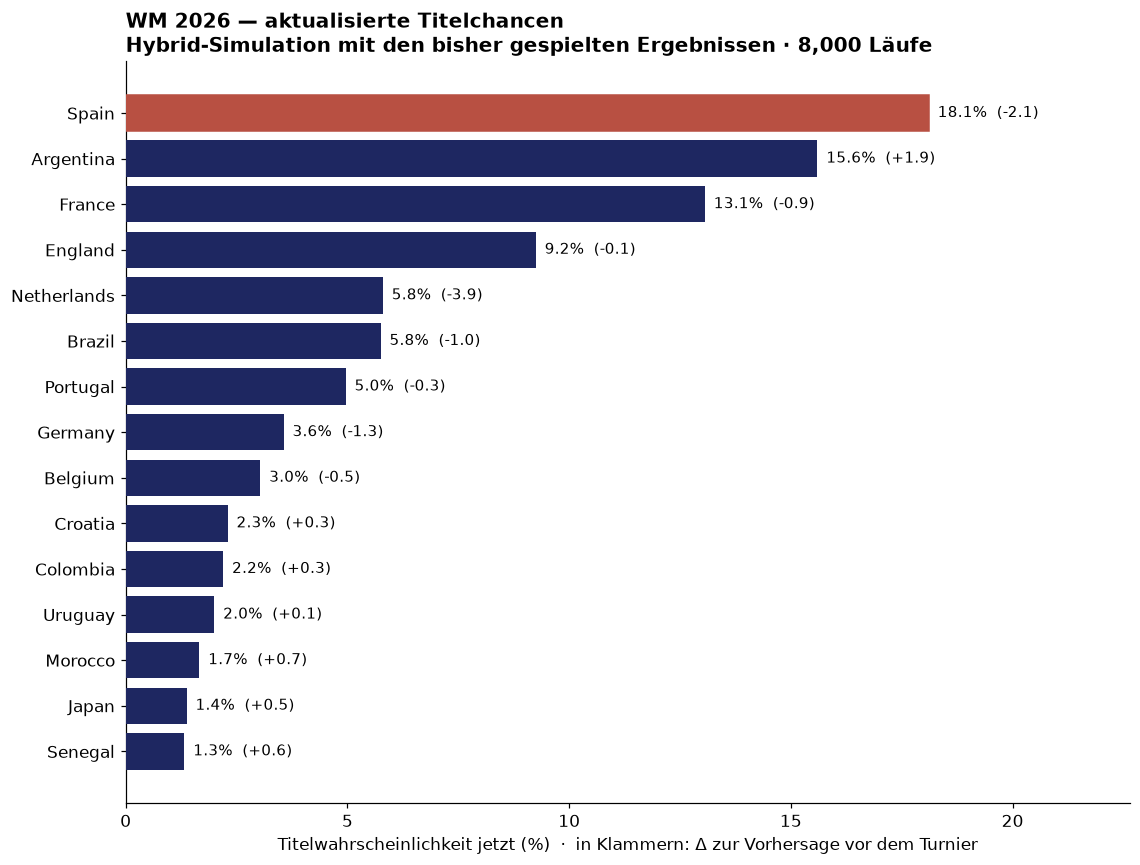

In [9]:
base = None
try:
    b = pd.read_csv("model_title_probabilities.csv")[["team","consensus"]]
    base = dict(zip(b.team, b.consensus))
except Exception:
    pass
top = prob.head(15).iloc[::-1]
fig, ax = plt.subplots(figsize=(10.5, 8))
bars = ax.barh(top["Team"], top["Titel"], color=NAVY, zorder=3); bars[-1].set_color(RED)
for i,(t,v) in enumerate(zip(top["Team"], top["Titel"])):
    txt = f"{v:.1f}%"
    if base and t in base:
        d = v - base[t]; txt += f"  ({'+' if d>=0 else ''}{d:.1f})"
    ax.text(v+0.2, i, txt, va="center", fontsize=10)
ax.set_xlabel("Titelwahrscheinlichkeit jetzt (%)  ·  in Klammern: Δ zur Vorhersage vor dem Turnier")
ax.set_title("WM 2026 — aktualisierte Titelchancen\n"
             f"Hybrid-Simulation mit den bisher gespielten Ergebnissen · {N_SIM:,} Läufe", loc="left")
ax.set_xlim(0, top["Titel"].max()*1.25)
plt.tight_layout(); plt.savefig("nb_live_title_odds.png"); plt.show()


### 6.3 Verlauf der Titelchancen über die Spieltage

Für jeden bereits gespielten Spieltag (Datum) rechnen wir die Titelchance neu —
mit *nur* den bis dahin bekannten Ergebnissen, der Rest simuliert (gleiches
Poisson-Modell, 3 000 Läufe). So sieht man, wie die Resultate die Favoriten
verschoben haben. „Start" = vor dem ersten Spiel (reine Vorhersage).

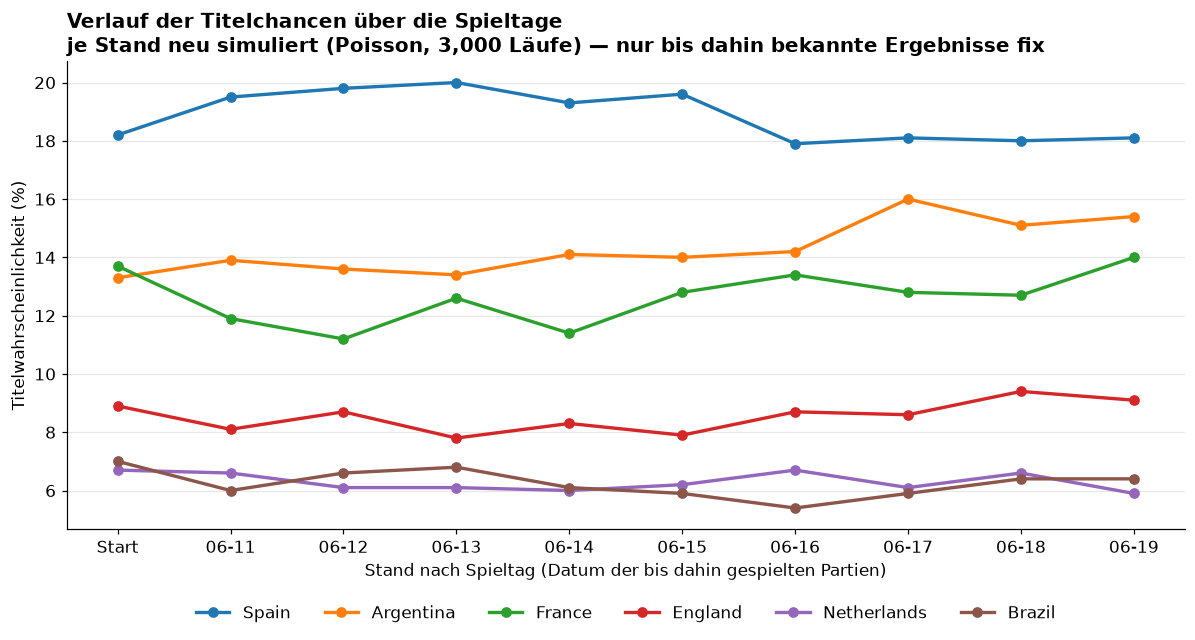

,Stand,Spain,Argentina,France,England,Netherlands,Brazil
0,Start,18.2,13.3,13.7,8.9,6.7,7.0
1,06-11,19.5,13.9,11.9,8.1,6.6,6.0
2,06-12,19.8,13.6,11.2,8.7,6.1,6.6
3,06-13,20.0,13.4,12.6,7.8,6.1,6.8
4,06-14,19.3,14.1,11.4,8.3,6.0,6.1
5,06-15,19.6,14.0,12.8,7.9,6.2,5.9
6,06-16,17.9,14.2,13.4,8.7,6.7,5.4
7,06-17,18.1,16.0,12.8,8.6,6.1,5.9
8,06-18,18.0,15.1,12.7,9.4,6.6,6.4
9,06-19,18.1,15.4,14.0,9.1,5.9,6.4


In [10]:
def sim_at(pk, n=3000):
    """Eine Simulationsrunde liefert beides: Titel- und Achtelfinal-Quote je Team."""
    champ = np.zeros(len(TEAMS)); adv = np.zeros(len(TEAMS))
    for _ in range(n):
        s = one_sim(pk)
        champ[ix[s["champ"][0]]] += 1
        for t in s["r32"]: adv[ix[t]] += 1
    return champ/n*100, adv/n*100

N_EVO = 3000
played_dates = sorted(grp_played["date"].astype(str).unique())
cutoffs = [("Start", None)] + [(d[5:], d) for d in played_dates]   # Label ohne Jahr

title_mat, adv_mat, labels = [], [], []
for label, cut in cutoffs:
    if cut is None:
        pk = {}
    else:
        sub = grp_played[grp_played["date"].astype(str) <= cut]
        pk = {(m.group, m.team1, m.team2): (int(m.score1), int(m.score2))
              for _, m in sub.iterrows() if m.team1 in STRENGTH and m.team2 in STRENGTH}
    tc, ac = sim_at(pk, N_EVO)
    title_mat.append(tc); adv_mat.append(ac); labels.append(label)
evo_title = pd.DataFrame(title_mat, columns=TEAMS, index=labels).round(1)
evo_adv   = pd.DataFrame(adv_mat,   columns=TEAMS, index=labels).round(1)

top_teams = prob.head(6)["Team"].tolist()
fig, ax = plt.subplots(figsize=(11, 6))
x = range(len(labels))
for t in top_teams:
    ax.plot(x, evo_title[t], marker="o", lw=2.2, label=t)
ax.set_xticks(list(x)); ax.set_xticklabels(labels, rotation=0)
ax.set_ylabel("Titelwahrscheinlichkeit (%)")
ax.set_xlabel("Stand nach Spieltag (Datum der bis dahin gespielten Partien)")
ax.set_title("Verlauf der Titelchancen über die Spieltage\n"
             f"je Stand neu simuliert (Poisson, {N_EVO:,} Läufe) — nur bis dahin bekannte Ergebnisse fix",
             loc="left")
ax.legend(ncol=6, frameon=False, loc="upper center", bbox_to_anchor=(0.5, -0.13))
ax.grid(axis="y", alpha=.3)
plt.tight_layout(); plt.savefig("nb_live_title_evolution.png"); plt.show()
evolution = evo_title[top_teams].reset_index().rename(columns={"index": "Stand"})
evolution


### 6.4 Verlauf: Achtelfinale (Runde der 32) erreichen — die offensten Rennen

Dieselbe Logik, aber für die **Qualifikation fürs Achtelfinale**. Gezeigt werden
die sechs Teams, deren Einzug aktuell am knappsten ist (am nächsten an der
50-%-Linie) — dort bewegt sich von Spieltag zu Spieltag am meisten.

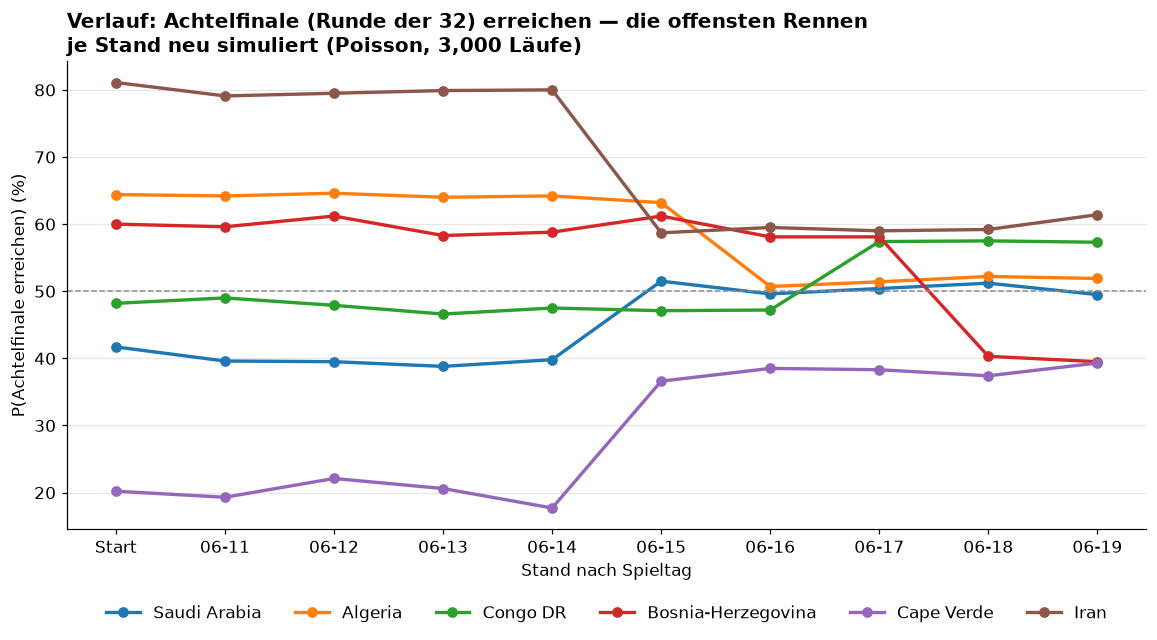

,Stand,Saudi Arabia,Algeria,Congo DR,Bosnia-Herzegovina,Cape Verde,Iran
0,Start,41.7,64.4,48.2,60.0,20.2,81.1
1,06-11,39.6,64.2,49.0,59.6,19.3,79.1
2,06-12,39.5,64.6,47.9,61.2,22.1,79.5
3,06-13,38.8,64.0,46.6,58.3,20.6,79.9
4,06-14,39.8,64.2,47.5,58.8,17.7,80.0
5,06-15,51.5,63.2,47.1,61.2,36.6,58.7
6,06-16,49.6,50.7,47.2,58.1,38.5,59.5
7,06-17,50.4,51.4,57.4,58.1,38.3,59.0
8,06-18,51.2,52.2,57.5,40.3,37.4,59.2
9,06-19,49.5,51.9,57.3,39.5,39.3,61.4


In [11]:
latest = evo_adv.iloc[-1]
mid = latest[(latest > 5) & (latest < 95)]
contested = (mid.sub(50).abs().sort_values().index[:6].tolist() if len(mid) >= 6
             else latest.sub(50).abs().sort_values().index[:6].tolist())

fig, ax = plt.subplots(figsize=(11, 6))
x = range(len(evo_adv))
for t in contested:
    ax.plot(x, evo_adv[t], marker="o", lw=2.2, label=t)
ax.axhline(50, color=GREY, ls="--", lw=1)
ax.set_xticks(list(x)); ax.set_xticklabels(evo_adv.index, rotation=0)
ax.set_ylabel("P(Achtelfinale erreichen) (%)")
ax.set_xlabel("Stand nach Spieltag")
ax.set_title("Verlauf: Achtelfinale (Runde der 32) erreichen — die offensten Rennen\n"
             f"je Stand neu simuliert (Poisson, {N_EVO:,} Läufe)", loc="left")
ax.legend(ncol=6, frameon=False, loc="upper center", bbox_to_anchor=(0.5, -0.13))
ax.grid(axis="y", alpha=.3)
plt.tight_layout(); plt.savefig("nb_live_advance_evolution.png"); plt.show()
advance_evolution = evo_adv[contested].reset_index().rename(columns={"index": "Stand"})
advance_evolution


## 7. Sobald die Gruppen entschieden sind: das K.-o.-Bracket füllen

Diese Funktion projiziert mit den **aktuell wahrscheinlichsten** Platzierungen
(gespielte Ergebnisse + wahrscheinlichstes Ergebnis der Restspiele) das
Round-of-32 und sagt jede Partie voraus. **Sind alle Gruppenspiele gespielt, ist
das die echte K.-o.-Runde** — derselbe Code, dann ohne Projektion.

In [12]:
def project_bracket(sched, R=STRENGTH):
    st = {g:{t:[0,0,0] for t in GROUPS[g]} for g in GROUPS}
    for g, a, b in fixtures:
        if (g,a,b) in played_key: x, y = played_key[(g,a,b)]
        else:
            P, la, lb = scoreline(a, b, R); n=P.shape[0]; i,j = divmod(int(np.argmax(P)), n); x,y=i,j
        st[g][a][1]+=x-y; st[g][a][2]+=x; st[g][b][1]+=y-x; st[g][b][2]+=y
        if x>y: st[g][a][0]+=3
        elif y>x: st[g][b][0]+=3
        else: st[g][a][0]+=1; st[g][b][0]+=1
    pos = {}; thirds = []
    for g in GROUPS:
        order = sorted(GROUPS[g], key=lambda t:(st[g][t][0],st[g][t][1],st[g][t][2],R[t]), reverse=True)
        pos[f"1{g}"], pos[f"2{g}"] = order[0], order[1]
        s = st[g][order[2]]; thirds.append((g, order[2], s[0], s[1], s[2], R[order[2]]))
    thirds.sort(key=lambda r:(r[2],r[3],r[4],r[5]), reverse=True)
    best8 = [(g,t) for g,t,*_ in thirds[:8]]
    tmap = assign_thirds(best8)
    rows = []
    for m, s1, s2 in R32:
        t1 = tmap[m] if s1.startswith("3:") else pos[s1]
        t2 = tmap[m] if s2.startswith("3:") else pos[s2]
        w, d, l = wdl_consensus(t1, t2, R); s, p = modal_score(t1, t2, R); la, lb = lam(t1, t2, R)
        fav = t1 if w>=l else t2
        rows.append({"R32":m,"Begegnung":f"{t1} – {t2}","Ø Tore (λ)":f"{la:.1f} : {lb:.1f}",
                     "P(Sieg 1)":w*100,"P(Remis)":d*100,
                     "P(Sieg 2)":l*100,"Favorit":fav,"wahrsch. Erg.":s})
    return pd.DataFrame(rows)

all_grp_done = len(grp_played) == n_grp
bracket = project_bracket(sched)
cap = ("ECHTES Round of 32 (alle Gruppen entschieden)" if all_grp_done
       else "Projiziertes Round of 32 (Stand heute — ändert sich mit den Restspielen)")
cap += " · W/U/N-Konsens aus 5 Modellen · λ = erwartete Tore (Poisson)"
(bracket.style.hide(axis="index")
   .format({"P(Sieg 1)":"{:.0f}%","P(Remis)":"{:.0f}%","P(Sieg 2)":"{:.0f}%"})
   .background_gradient(cmap="Greens", subset=["P(Sieg 1)"])
   .background_gradient(cmap="Reds",   subset=["P(Sieg 2)"])
   .set_caption(cap))


R32,Begegnung,Ø Tore (λ),P(Sieg 1),P(Remis),P(Sieg 2),Favorit,wahrsch. Erg.
73,South Korea – Switzerland,1.1 : 1.3,26%,27%,48%,Switzerland,1:1
74,Germany – Scotland,1.6 : 0.9,62%,22%,16%,Germany,1:0
75,Netherlands – Morocco,1.5 : 1.0,56%,24%,20%,Netherlands,1:0
76,Brazil – Japan,1.5 : 1.0,48%,27%,25%,Brazil,1:0
77,France – Paraguay,2.2 : 0.6,69%,20%,11%,France,2:0
78,Ivory Coast – Norway,1.1 : 1.3,31%,28%,41%,Norway,1:1
79,Mexico – Senegal,1.0 : 1.3,35%,27%,38%,Senegal,1:1
80,England – Algeria,1.8 : 0.8,62%,23%,15%,England,1:0
81,United States – Ecuador,1.1 : 1.3,36%,28%,36%,Ecuador,1:1
82,Belgium – Czechia,1.5 : 0.9,53%,25%,22%,Belgium,1:0


## 8. A/B: statische Vorab-Stärke vs. laufendes WM-Elo

Alle bisherigen Match-Prognosen nutzen den **statischen** Vor-Turnier-`STRENGTH`.
Hier der Vergleich mit einem **laufenden Elo**, das aus den **gespielten
WM-Ergebnissen** mitläuft (Start = `STRENGTH`, K=30) — so spiegeln die Prognosen
die aktuelle Turnierform wider, ganz **ohne manuelle Pflege** der Stärke-Werte.

In [13]:
def running_elo(prior, K=30.0):
    e = dict(prior)
    for _, m in grp_played.sort_values("date").iterrows():
        h, a = m.team1, m.team2
        if h not in e or a not in e: continue
        gh, ga = int(m.score1), int(m.score2)
        eh, ea = e[h], e[a]; exp = 1/(1+10**((ea-eh)/400))
        s = 1.0 if gh>ga else (0.5 if gh==ga else 0.0)
        e[h] += K*(s-exp); e[a] += K*((1-s)-(1-exp))
    return e

STRENGTH_LIVE = running_elo(STRENGTH)
mov = pd.DataFrame({"Team": TEAMS, "Vorab": [STRENGTH[t] for t in TEAMS],
                    "Laufend": [round(STRENGTH_LIVE[t]) for t in TEAMS]})
mov["Δ Elo"] = mov.Laufend - mov.Vorab
mov = mov.reindex(mov["Δ Elo"].abs().sort_values(ascending=False).index).head(14)
display(mov.style.hide(axis="index").format({"Vorab":"{:.0f}","Laufend":"{:.0f}","Δ Elo":"{:+.0f}"})
        .background_gradient(cmap="RdYlGn", subset=["Δ Elo"])
        .set_caption("Größte Elo-Bewegungen aus den gespielten WM-Ergebnissen (laufend vs. statisch)"))


Team,Vorab,Laufend,Δ Elo
Türkiye,1840,1800,-40
Czechia,1815,1792,-23
United States,1805,1828,+23
Mexico,1820,1842,+22
Ivory Coast,1800,1817,+17
Ecuador,1840,1823,-17
Morocco,1900,1915,+15
Spain,2165,2151,-14
Cape Verde,1555,1569,+14
Ghana,1750,1761,+11


### 8.1 Nächste Spiele — statische vs. laufende Stärke

In [14]:
def _fav(w, a, b): return a if w[0] >= w[2] else b
rows = []
for _, m in upcoming.head(12).iterrows():
    a, b = m.team1, m.team2
    ls = lam(a, b, STRENGTH); lr = lam(a, b, STRENGTH_LIVE)
    ws = wdl_consensus(a, b, STRENGTH); wr = wdl_consensus(a, b, STRENGTH_LIVE)
    rows.append({"Begegnung": f"{a} – {b}",
                 "λ statisch": f"{ls[0]:.1f} : {ls[1]:.1f}", "λ laufend": f"{lr[0]:.1f} : {lr[1]:.1f}",
                 "Favorit stat.": _fav(ws,a,b), "Favorit lauf.": _fav(wr,a,b),
                 "P(Sieg1) stat.": ws[0]*100, "P(Sieg1) lauf.": wr[0]*100})
ab_next = pd.DataFrame(rows)
(ab_next.style.hide(axis="index")
   .format({"P(Sieg1) stat.":"{:.0f}%","P(Sieg1) lauf.":"{:.0f}%"})
   .set_caption("Nächste Spiele: statisch vs. laufend — erwartete Tore λ, Favorit, P(Sieg erstgenannt)"))


Begegnung,λ statisch,λ laufend,Favorit stat.,Favorit lauf.,P(Sieg1) stat.,P(Sieg1) lauf.
Tunisia – Japan,0.9 : 1.6,0.8 : 1.7,Japan,Japan,22%,21%
Germany – Ivory Coast,1.5 : 0.9,1.5 : 0.9,Germany,Germany,57%,57%
Ecuador – Curacao,2.0 : 0.7,1.9 : 0.7,Ecuador,Ecuador,66%,66%
Netherlands – Sweden,1.7 : 0.8,1.6 : 0.9,Netherlands,Netherlands,58%,57%
Uruguay – Cape Verde,2.2 : 0.6,2.1 : 0.7,Uruguay,Uruguay,73%,72%
Spain – Saudi Arabia,2.7 : 0.5,2.6 : 0.5,Spain,Spain,79%,78%
New Zealand – Egypt,0.7 : 1.9,0.8 : 1.9,Egypt,Egypt,29%,29%
Belgium – Iran,1.5 : 0.9,1.5 : 0.9,Belgium,Belgium,55%,55%
Norway – Senegal,1.1 : 1.3,1.1 : 1.2,Senegal,Senegal,34%,35%
France – Iraq,2.5 : 0.6,2.5 : 0.6,France,France,79%,79%


### 8.2 Titelchancen — statische vs. laufende Stärke (je eigene Simulation)

Team,statisch,laufend,Δ
Spain,18.1%,16.4%,-1.7
Argentina,15.6%,15.6%,+0.0
France,13.1%,14.3%,+1.3
England,9.2%,10.0%,+0.8
Brazil,5.8%,5.9%,+0.2
Netherlands,5.8%,5.6%,-0.2
Portugal,5.0%,4.3%,-0.7
Germany,3.6%,3.8%,+0.2
Belgium,3.0%,3.0%,+0.0
Morocco,1.7%,2.1%,+0.4


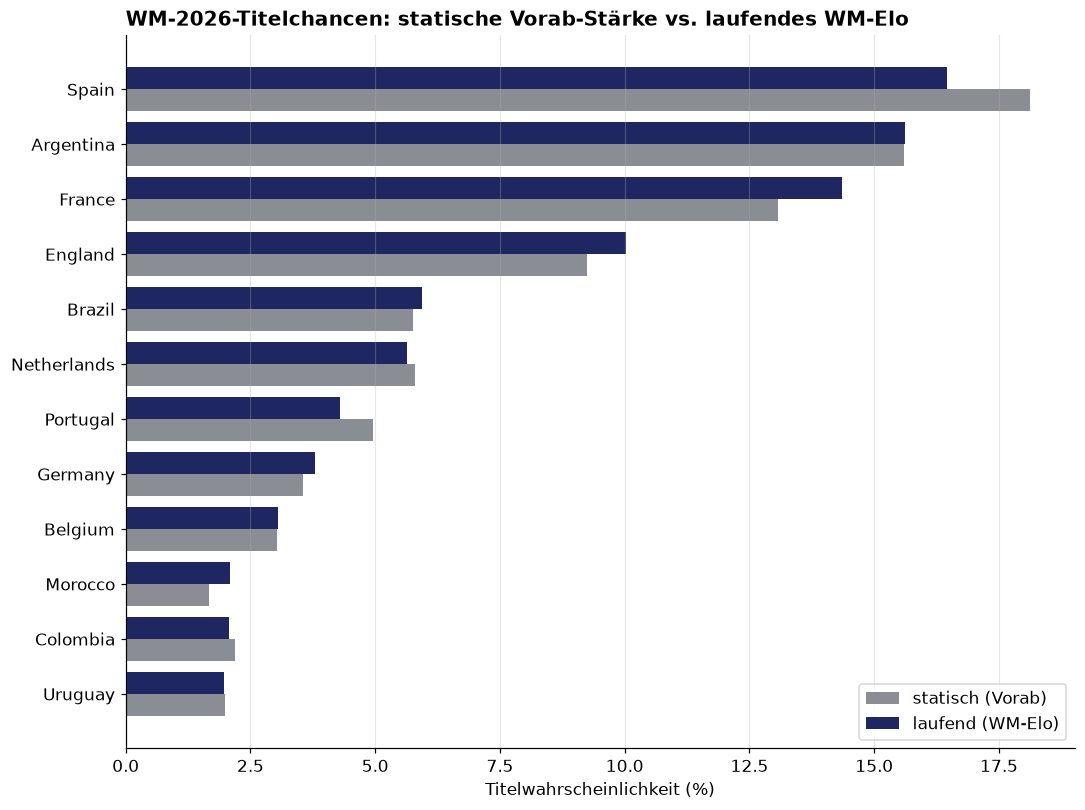

In [15]:
# volle Lauf-Variante mit laufendem Elo (unten auch separat gespeichert)
prob_live    = run_full_sim(STRENGTH_LIVE, N_SIM)
nxt_live     = next_matches(sched, R=STRENGTH_LIVE)
bracket_live = project_bracket(sched, R=STRENGTH_LIVE)

cmp = (prob[["Team","Titel"]].rename(columns={"Titel":"statisch"})
       .merge(prob_live[["Team","Titel"]].rename(columns={"Titel":"laufend"}), on="Team"))
cmp["Δ"] = cmp.laufend - cmp.statisch
cmp = cmp.sort_values("laufend", ascending=False).head(12).reset_index(drop=True)
display(cmp.style.hide(axis="index").format({"statisch":"{:.1f}%","laufend":"{:.1f}%","Δ":"{:+.1f}"})
        .background_gradient(cmap="RdYlGn", subset=["Δ"])
        .set_caption(f"Titelchancen: statisch vs. laufend · je {N_SIM:,} Simulationen"))

top = cmp.iloc[::-1]; yy = np.arange(len(top)); w = 0.4
fig, ax = plt.subplots(figsize=(10, 7.5))
ax.barh(yy-w/2, top.statisch, w, color=GREY, label="statisch (Vorab)")
ax.barh(yy+w/2, top.laufend,  w, color=NAVY, label="laufend (WM-Elo)")
ax.set_yticks(yy); ax.set_yticklabels(top.Team); ax.set_xlabel("Titelwahrscheinlichkeit (%)")
ax.set_title("WM-2026-Titelchancen: statische Vorab-Stärke vs. laufendes WM-Elo", loc="left")
ax.legend(); ax.grid(axis="x", alpha=.3)
plt.tight_layout(); plt.savefig("nb_live_ab_title.png"); plt.show()


## 9. Ergebnisse mit Zeitstempel speichern (zum Vergleichen)

Jeder Lauf wird unter `results/<Zeitstempel>_*.csv` abgelegt — Tabellen,
Prognosen, Wahrscheinlichkeiten und Bracket, **jeweils in beiden Varianten**:
statisch (Vorab-Stärke) **und** `_live` (laufendes WM-Elo). Zusätzlich werden die
Titelchancen je Team an `results/title_history.csv` (statisch) und
`results/title_history_live.csv` (laufend) angehängt, sodass man die Entwicklung
über mehrere Läufe **und** den Effekt der laufenden Stärke direkt vergleichen kann.

In [16]:
from datetime import datetime
RESULTS = Path("results"); RESULTS.mkdir(exist_ok=True)
STAMP = datetime.now().strftime("%Y-%m-%dT%H-%M-%S")

meta = pd.Series({
    "timestamp": STAMP, "quelle": source,
    "gespielte_gruppenspiele": int(len(grp_played)), "gruppenspiele_gesamt": int(n_grp),
    "n_sim": int(N_SIM), "match_modelle": ", ".join(MATCH_MODELS), "sim_modell": SIM_MODEL,
})
saved = []
for name, df in [("standings", tables), ("next_matches", nxt), ("probabilities", prob),
                 ("bracket", bracket), ("title_evolution", evolution),
                 ("advance_evolution", advance_evolution),
                 ("next_matches_live", nxt_live), ("probabilities_live", prob_live),
                 ("bracket_live", bracket_live)]:
    fp = RESULTS / f"{STAMP}_{name}.csv"; df.to_csv(fp, index=False); saved.append(fp.name)
meta.to_csv(RESULTS / f"{STAMP}_run_info.csv", header=False)

# long-format title history — beide Varianten getrennt — für den Zeitvergleich
for src_df, fn in [(prob, "title_history.csv"), (prob_live, "title_history_live.csv")]:
    h = src_df[["Team", "Titel"]].copy(); h.insert(0, "run", STAMP)
    hp = RESULTS / fn; h.to_csv(hp, mode="a", header=not hp.exists(), index=False)
hpath = RESULTS / "title_history.csv"

print(f"Lauf {STAMP} gespeichert in results/  ({len(saved)} Dateien, statisch + _live):")
for s in saved + [f"{STAMP}_run_info.csv"]: print("   -", s)
print("   - title_history.csv / title_history_live.csv  (Titelchancen je Variante & Lauf)")

# Vergleich: wie haben sich die Titelchancen über die bisherigen Läufe entwickelt?
comp = (pd.read_csv(hpath).pivot_table(index="Team", columns="run", values="Titel")
          .reindex(prob.head(8).Team))
if comp.shape[1] > 1:
    print("\nTitelchancen-Verlauf (Top 8, %):")
    display(comp.round(1))
else:
    print("\n(Beim nächsten Lauf erscheint hier ein Verlaufsvergleich über die Zeit.)")


Lauf 2026-06-20T16-40-41 gespeichert in results/  (9 Dateien, statisch + _live):
   - 2026-06-20T16-40-41_standings.csv
   - 2026-06-20T16-40-41_next_matches.csv
   - 2026-06-20T16-40-41_probabilities.csv
   - 2026-06-20T16-40-41_bracket.csv
   - 2026-06-20T16-40-41_title_evolution.csv
   - 2026-06-20T16-40-41_advance_evolution.csv
   - 2026-06-20T16-40-41_next_matches_live.csv
   - 2026-06-20T16-40-41_probabilities_live.csv
   - 2026-06-20T16-40-41_bracket_live.csv
   - 2026-06-20T16-40-41_run_info.csv
   - title_history.csv / title_history_live.csv  (Titelchancen je Variante & Lauf)

Titelchancen-Verlauf (Top 8, %):


run,2026-06-17T21-53-06,2026-06-19T22-01-25,2026-06-20T16-40-41
Team,,,
Spain,17.2,18.3,18.1
Argentina,15.5,15.1,15.6
France,13.0,12.4,13.1
England,8.6,9.0,9.2
Netherlands,6.2,6.1,5.8
Brazil,6.3,5.7,5.8
Portugal,5.1,5.1,5.0
Germany,3.6,3.7,3.6


## 10. Was muss aktualisiert werden?

Damit die Prognosen aktuell und korrekt bleiben:

| Was | Wie | Wann |
|-----|-----|------|
| **Gespielte Ergebnisse** | `python refresh_data.py` (lädt `data/wc2026_results.csv` neu) → Notebook neu ausführen | nach jedem Spieltag |
| **Team-Stärken** (`STRENGTH`) | optional von [eloratings.net](https://www.eloratings.net/) auffrischen — **oder** das **laufende Elo aus §8** nutzen (aktualisiert sich automatisch aus den Ergebnissen, kein Hand-Pflegen) | optional |
| **Playoff-Sieger** (März 2026) | falls abweichend, in `GROUPS`/`STRENGTH` korrigieren (hier: Czechia, Bosnia-Herzegovina, Türkiye, Sweden, Iraq, Congo DR) | einmalig, sobald bekannt |
| **K.-o.-Resultate mit Verlängerung/Elfmeter** | openfootball führt den 90-Minuten-Stand; Sieger eines im Elfmeterschießen entschiedenen Spiels ggf. manuell setzen | in der K.-o.-Phase |
| **Trainingsdaten** (optional) | `python refresh_data.py --training` → `data/*_refreshed.csv` prüfen und ersetzen | selten |
| **Markt-Quoten** (für den Benchmark) | im Suite-Skript auffrischen | optional |

Das meiste erledigt **`refresh_data.py`** automatisch. Nach dem Aktualisieren
einfach *Run All* — Tabellen, Prognosen und Titelchancen rechnen sich neu.

## 11. Können die Datendateien heruntergeladen werden?

**Ja.** Alle Daten stammen aus dem öffentlichen **openfootball**-Projekt (Public
Domain) und werden über `raw.githubusercontent.com` geladen:

* **WM 2026** (Spielplan + Ergebnisse): `worldcup.json/master/2026/worldcup.json`
* **WM 2010–2022** & **EM 2020/2024** (Trainingsdaten): analog je Jahr.

`refresh_data.py` lädt und normalisiert die Namen (z. B. *Czech Republic → Czechia*,
*Turkey → Türkiye*) passend zu den Modellen. Quoten von Wettanbietern und die
Elo-Stärken sind **nicht** frei abrufbar (eloratings.net blockt automatisierte
Zugriffe) und werden im Code gepflegt — siehe `data/SOURCES.md`.

In [17]:
# Direkt aus dem Notebook aktualisieren (lädt data/wc2026_results.csv neu):
import subprocess, sys
res = subprocess.run([sys.executable, "refresh_data.py"], capture_output=True, text=True)
print(res.stdout or res.stderr)
print("Danach dieses Notebook neu ausführen (Run All), um alles zu aktualisieren.")


wc2026_results.csv  ·  104 matches, 32 played (32/72 group games).

Danach dieses Notebook neu ausführen (Run All), um alles zu aktualisieren.


---
*Aus* **Soccer Analytics with Machine Learning** *(O'Reilly, 2026). Daten:
openfootball (Public Domain). Stärke-Werte & Quoten sind ein illustrativer Snapshot —
vor Veröffentlichung auffrischen.*